<a href="https://colab.research.google.com/github/Salma5806/balance-sheet-recognition/blob/main/layoutlvm3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

salma78_jsson_file_path = kagglehub.dataset_download('salma78/jsson-file')
salma78_images_new_img_path = kagglehub.dataset_download('salma78/images-new-img')
salma78_bilan_load_path = kagglehub.dataset_download('salma78/bilan-load')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import json
from tqdm import tqdm

from sklearn.model_selection import train_test_split
import os
import ast
from pathlib import Path
import datasets
from PIL import Image
import pandas as pd

In [ ]:
def load_annotation_file(json_path):
    """
    Load json file
    """
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

In [ ]:
def convert_bounding_box(x, y, width, height, original_width, original_height):
    """"""
    x1 = int((x * original_width) / 100)
    y1 = int((y * original_height) / 100)
    x2 = x1 + int(original_width * width / 100)
    y2 = y1 + int(original_height * height / 100)
    return [x1, y1, x2, y2]

In [ ]:
def prepare_data_for_layoutlmv3(data):
    """Prepare data for LayoutLMv3"""

    label_to_id = {"key": 0, "value": 1, "reference": 2, "Year": 3, "name": 4}
    final_list = []

    for entry in tqdm(data):
        label_text = {}
        word_list = []
        bboxes_list = []
        ner_tags_list = []

        image_path = f"{entry.get('ocr', '').split('8080/')[-1]}"
        label_text['file_name'] = image_path
        label_text['id'] = entry['id']

        original_width = entry['bbox'][0]['original_width']
        original_height = entry['bbox'][0]['original_height']

        for word, label_item in zip(entry['transcription'], entry['label']):
            label = label_item['labels'][0]
            bbox =  convert_bounding_box(
                label_item['x'], label_item['y'],
                label_item['width'], label_item['height'],
                original_width, original_height
            )

            if word.strip() == "":
                continue

            word_list.append(word.strip())
            bboxes_list.append(bbox)
            ner_tags_list.append(label_to_id.get(label, 0))

        label_text['tokens'] = word_list
        label_text['bboxes'] = bboxes_list
        label_text['ner_tags'] = ner_tags_list

        final_list.append(label_text)

    return final_list

In [ ]:
json_path = "/kaggle/input/jsson-file/detection.json"
data = load_annotation_file(json_path)
final_list = prepare_data_for_layoutlmv3(data)

100%|██████████| 85/85 [00:00<00:00, 7218.97it/s]


In [ ]:
print(final_list[50])

{'file_name': 'tt2.png', 'id': 325, 'tokens': ['Etat de Résultat', 'Période allant du 1er janvier au 31 Décembre 2023', '(Exprimé en Dinar tunisien)', 'Notes', '31/12/2023', '31/12/2022', "Produits d'exploitation de microfinance", 'Intérets et revenus assimilés', '35 237 903', '28 744 424', '2 397 183', '1 549 760', '733 454', 'Gains sur portefeuille-titres de placement a CT', '518 517', "Total produits d'exploitation de microfinance", '5.2.1', '38 153 603', '31 027 638', "Charges d'exploitation de microfinance", 'Intérets encourus et charges assimilées', '5.2.2', '(8 556 925)', '(7 063 538)', '5.2.3', '(969 131)', '(806 077)', 'Commissions encourues', "Total charges d'exploitation de microfinance", '(9 526 056)', '(7 869 615)', 'Produit net des activités de microfinance', '28 627 547', '23 158 023', "AUTRES PRODUITS ET CHARGES D'EXPLOITATION", 'PR 5  CH 4 - Dotations aux provisions et résultat des corrections de valeurs sur créances et passif', '5.2.4', '(1 757 267)', '(1 792 161)', "

In [ ]:
for i, item in enumerate(final_list):
        num_tokens = len(item["tokens"])
        num_bboxes = len(item["bboxes"])
        num_labels = len(item["ner_tags"])

        if (num_tokens == num_bboxes == num_labels):
            print(f"good")
        else:
             print(f"bad")

good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good
good


In [ ]:

train_data, test_data = train_test_split(
    final_list,
    train_size=68,
    test_size=17,
    random_state=21,
    shuffle=True
)

In [ ]:
def write_to_file(data, filename):
    with open(filename, 'a') as f:
        for detail in data:
            f.write(str(detail) + '\n')

write_to_file(final_list, 'final_list_text_5.txt')
write_to_file(train_data, 'train_5.txt')
write_to_file(test_data, 'test_5.txt')

In [ ]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from datasets import load_dataset
dataset = load_dataset("/kaggle/input/bilan-load/BalanceSheetExtraction2.py")

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'bboxes', 'ner_tags', 'image_path', 'image'],
        num_rows: 68
    })
    test: Dataset({
        features: ['id', 'tokens', 'bboxes', 'ner_tags', 'image_path', 'image'],
        num_rows: 17
    })
})


In [ ]:
sample = dataset['train'][60]

In [ ]:
sample.keys()

dict_keys(['id', 'tokens', 'bboxes', 'ner_tags', 'image_path', 'image'])

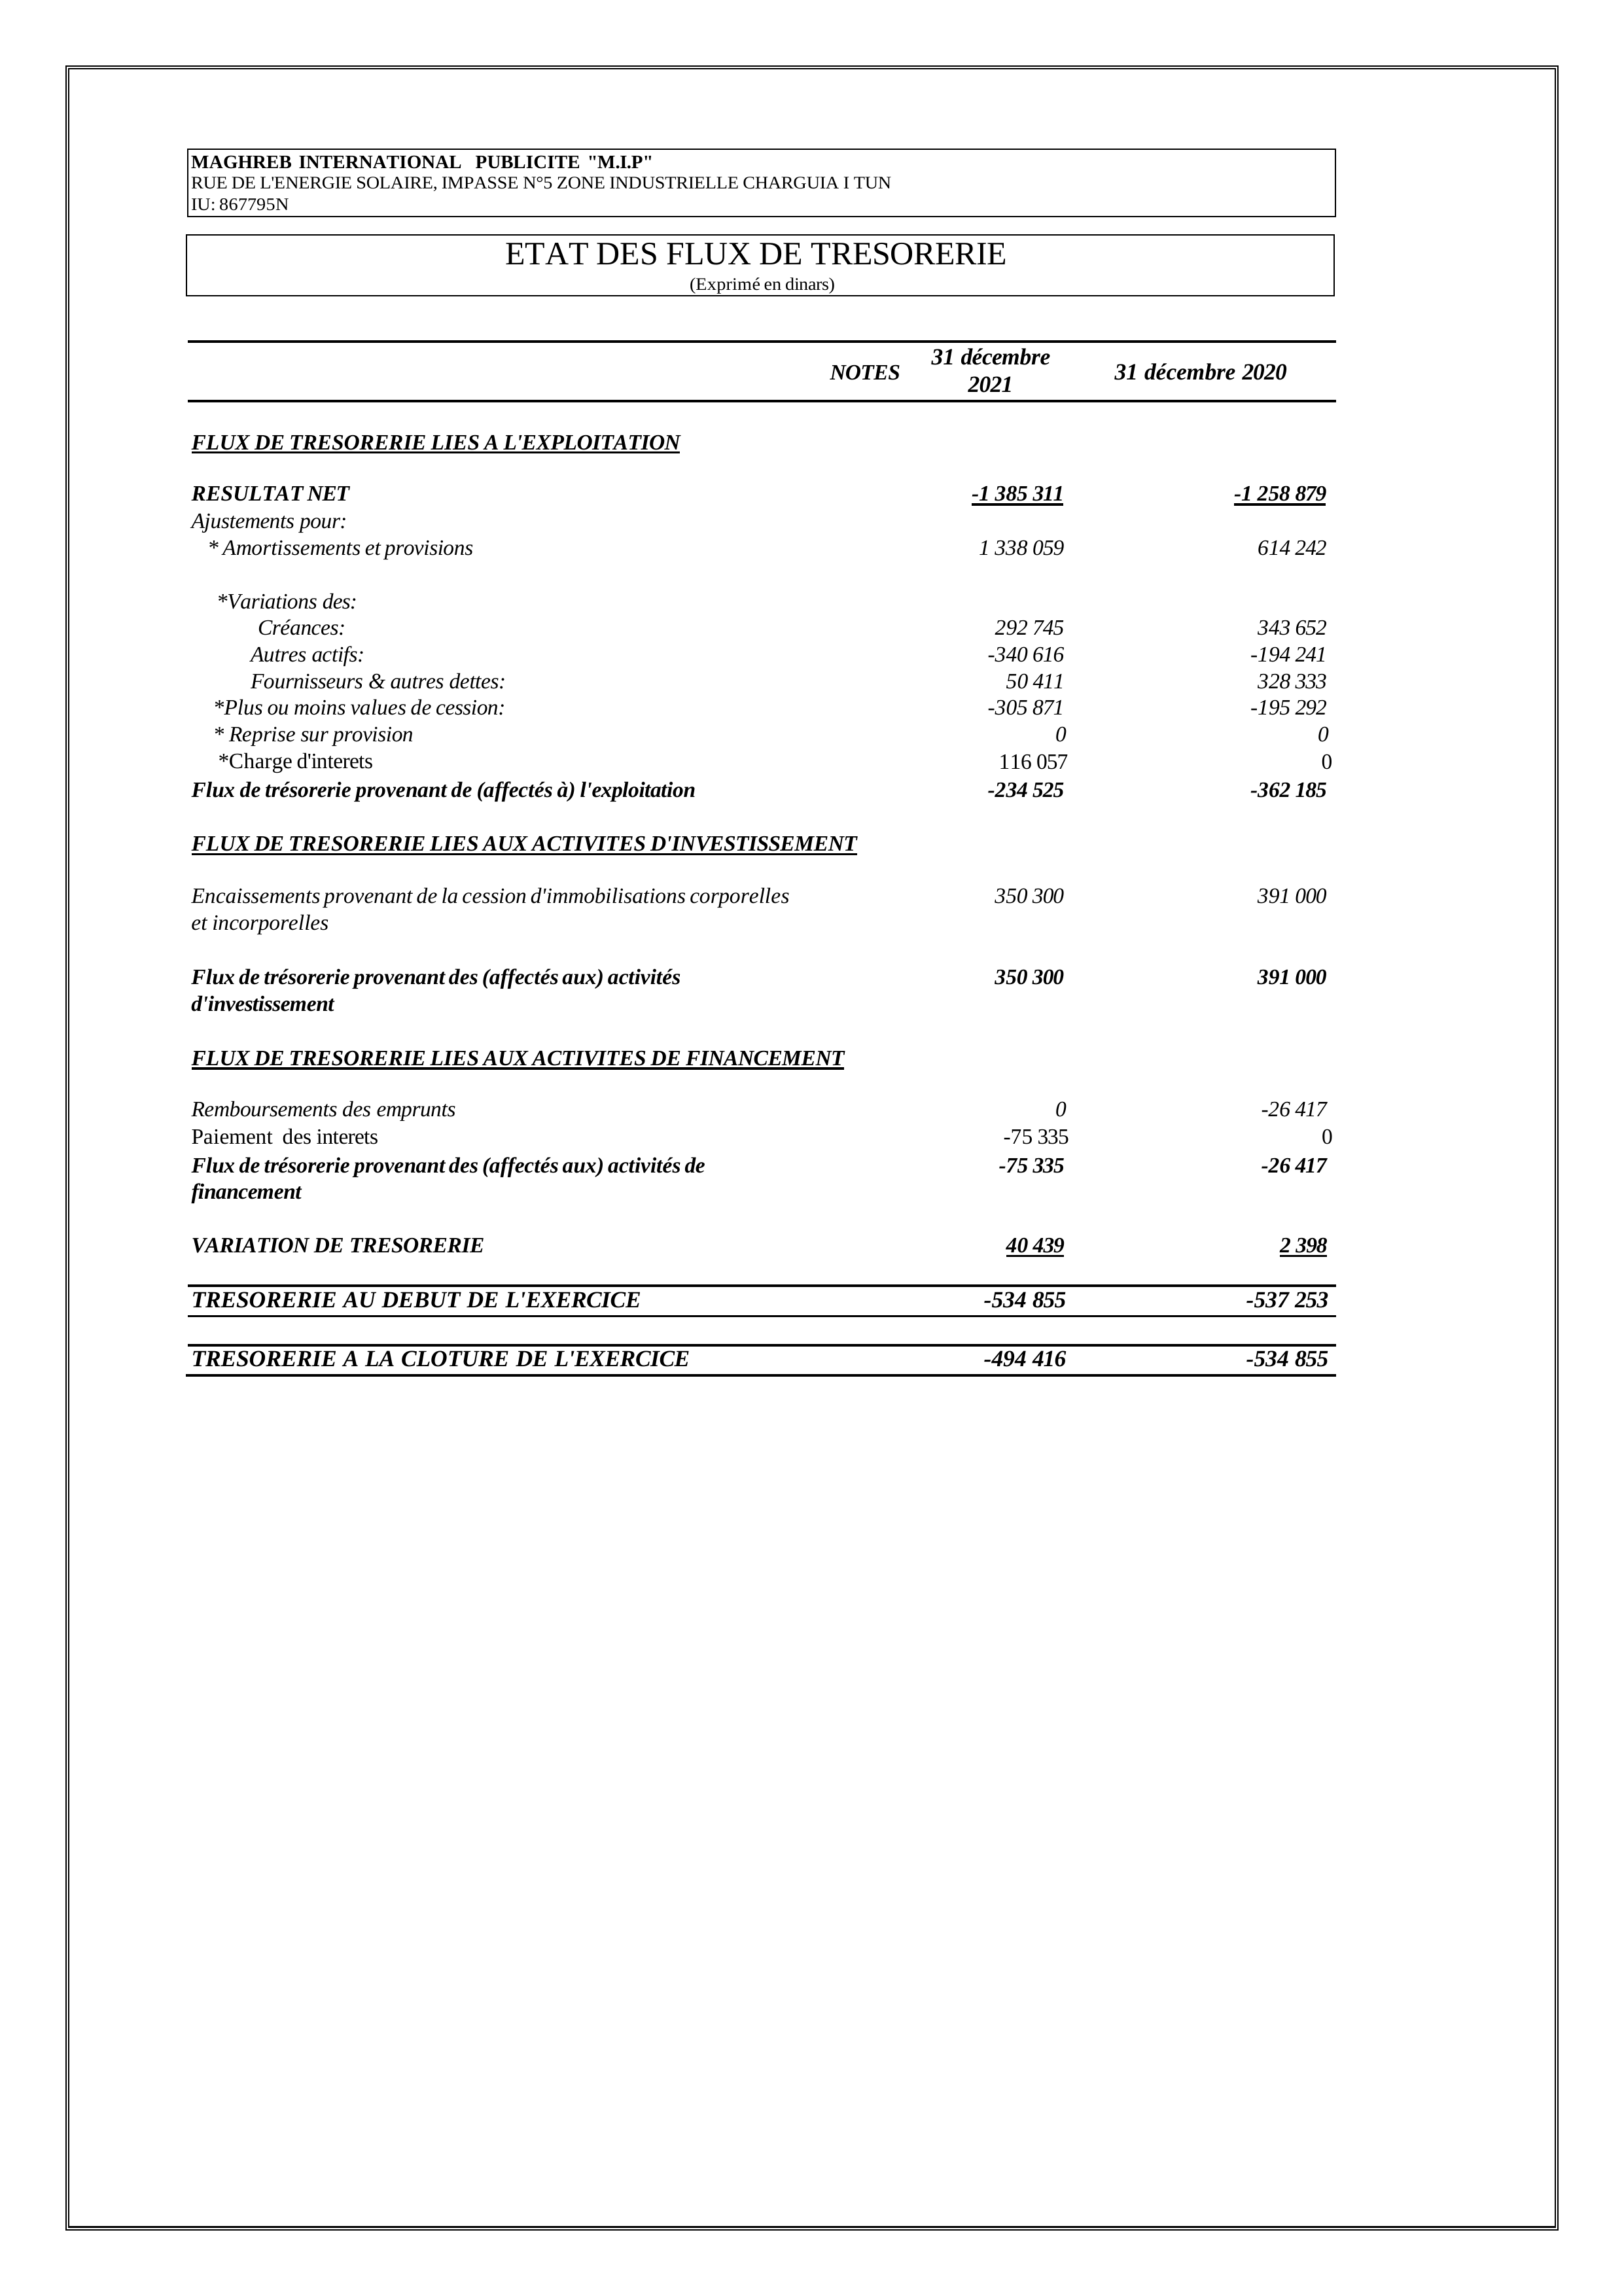

In [ ]:
sample['image']

In [ ]:
import albumentations as A

In [ ]:
!pip install -U albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.1/367.1 kB 9.5 MB/s eta 0:00:00:00:01
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.23
    Uninstalling albucore-0.0.23:
      Successfully uninstalled albucore-0.0.23
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.4
    Uninstalling albumentations-2.0.4:
      Successfully uninstalled albumentations-2.0.4


In [ ]:
photometric_transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.7),
    A.GaussNoise(p=0.5),  # ← ici la correction
    A.GaussianBlur(blur_limit=(3, 5), p=0.3)
])

In [ ]:
def augment_photometric(example):
    image = np.array(example['image'])
    transformed = photometric_transform(image=image)
    example['image'] = Image.fromarray(transformed['image'])
    return example

In [ ]:
sample = dataset['train'][50]

In [ ]:
import numpy as np
r = augment_photometric(sample)

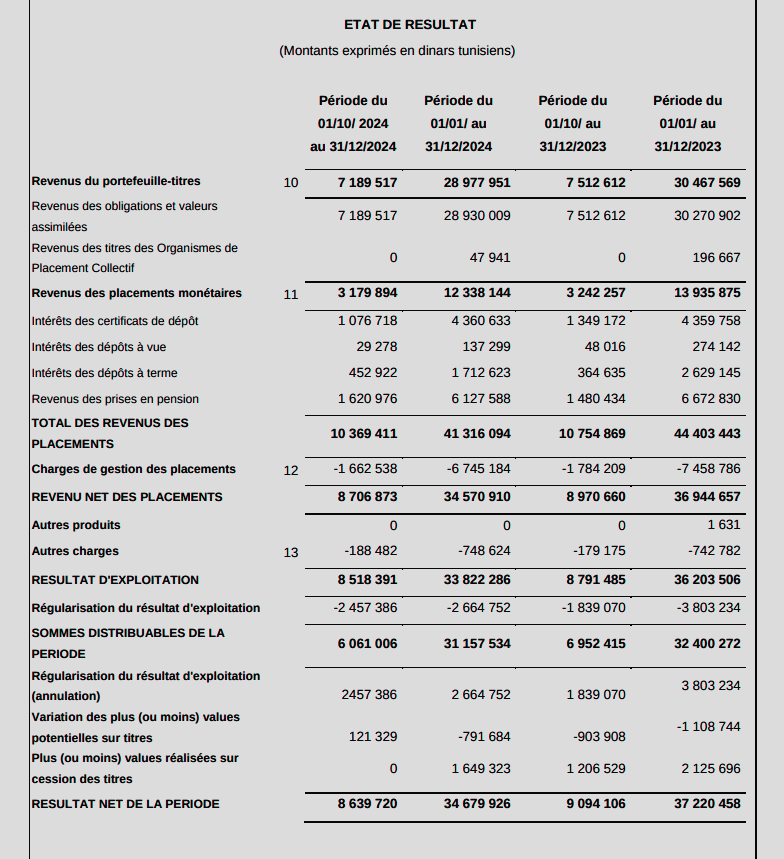

In [ ]:
r['image']

In [ ]:
augmented_dataset = dataset['train'].map(augment_photometric)

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

In [ ]:
from datasets import concatenate_datasets

dataset['train'] = concatenate_datasets([dataset['train'], augmented_dataset])

In [ ]:
words, boxes, ner_tags = sample["tokens"], sample["bboxes"], sample["ner_tags"]
print(words)
print(boxes)
print(ner_tags)

['ETAT DE RESULTAT', 'Montants exprimes en dinars tunisiens)', 'Période du 01/10/ 2024 au 31/12/2024', 'Période du 01/01/ au 31/12/2024', 'Période du 01/10/ au 31/12/2023', 'Période du 01/01/ au 31/12/2023', 'Revenus du portefeuille-titres', '10', '7 189 517', '28 977 951', '7 512 612', '30 467 569', 'Revenus des obligations et valeurs assimilées', '7 189 517', '28930009', '7 512 612', '30 270 902', 'Revenus des titres des Organismes de Placement Collectif', '0', '47 941', '0', '196 667', 'Revenus des placements monétaires', '11', '3 179 894', '12 338 144', '3 242 257', '13 935 875', 'Intéréts des certificats de dépot', '1 076 718', '4 360 633', '1 349 172', '4 359 758', 'Interéts des depöts a vue', '29 278', '137 299', '48 016', '274 142', 'Interéts des depöts a terme', '452 922', '1 712 623', '364 635', '2 629 145', 'Revenus des prises en pension', '1 620 976', '6 127 588', '1 480 434', '6 672 830', 'TOTAL DES REVENUS DES PLACEMENTS', '10369411', '41 316094', '10754869', '44 403 443'

In [ ]:
import numpy as np

def check_bbox_range(dataset):
    for split in ["train", "test"]:
        bboxes = dataset[split]["bboxes"]
        for i, bbox in enumerate(bboxes):
            bbox_array = np.array(bbox)
            if np.any(bbox_array < 0) or np.any(bbox_array > 1000):
                print(f"Split: {split}, Example {i}, Out-of-range bbox: {bbox_array}")
check_bbox_range(dataset)

Split: train, Example 32, Out-of-range bbox: [[  42   57  327   74]
 [  42   97  221  113]
 [ 631  135  730  150]
 [  46  176  251  191]
 [ 675  176  725  193]
 [ 789  176  840  194]
 [ 901  176  954  194]
 [  48  200  339  215]
 [ 671  199  727  216]
 [ 784  197  840  215]
 [ 896  199  954  216]
 [  45  242  293  259]
 [ 668  242  725  260]
 [ 783  241  842  259]
 [ 901  240  957  261]
 [  46  287  178  307]
 [ 709  286  728  302]
 [ 821  286  840  302]
 [ 936  286  954  302]
 [  46  308  172  326]
 [ 671  307  727  325]
 [ 786  307  839  323]
 [ 898  307  954  325]
 [  50  349  274  368]
 [ 666  352  727  368]
 [ 781  349  842  371]
 [ 901  349  957  369]
 [  46  395  378  412]
 [ 709  395  727  414]
 [ 821  395  840  414]
 [ 936  394  954  413]
 [  46  441  339  457]
 [ 671  440  727  458]
 [ 781  440  840  459]
 [ 901  440  954  458]
 [  45  485  450  501]
 [ 660  485  725  500]
 [ 789  484  840  500]
 [ 896  484  954  500]
 [  46  506  477  521]
 [ 674  505  725  522]
 [ 789  505 

In [ ]:
from PIL import Image
import numpy as np
from datasets import DatasetDict

# Fonction pour obtenir la taille d'une image
def get_image_size(image):
    # Si l'image est un objet PIL.Image
    if isinstance(image, Image.Image):
        return image.size  # Retourne (width, height)
    # Si l'image est un tableau NumPy
    elif isinstance(image, np.ndarray):
        # Supposons que le format est (height, width, channels) ou (channels, height, width)
        if len(image.shape) == 3:
            if image.shape[0] in [1, 3, 4]:  # Format (channels, height, width)
                return (image.shape[2], image.shape[1])
            else:  # Format (height, width, channels)
                return (image.shape[1], image.shape[0])
        else:
            raise ValueError(f"Format d'image non supporté : {image.shape}")
    else:
        raise ValueError(f"Type d'image non reconnu : {type(image)}")

# Fonction pour parcourir le dataset et afficher les tailles des images
def print_image_sizes(dataset: DatasetDict):
    for split in ["train", "test"]:
        print(f"\nDimensions des images dans le split '{split}':")
        for idx, example in enumerate(dataset[split]):
            image = example["image"]
            try:
                width, height = get_image_size(image)
                print(f"Exemple {idx}: width={width}, height={height}")
            except Exception as e:
                print(f"Exemple {idx}: Erreur lors de la récupération de la taille - {str(e)}")

# Exemple d'utilisation avec votre DatasetDict
# Remplacez 'dataset' par le nom de votre variable DatasetDict
print_image_sizes(dataset)


Dimensions des images dans le split 'train':
Exemple 0: width=748, height=871
Exemple 1: width=723, height=847
Exemple 2: width=717, height=871
Exemple 3: width=729, height=851
Exemple 4: width=2481, height=3509
Exemple 5: width=728, height=866
Exemple 6: width=721, height=864
Exemple 7: width=735, height=831
Exemple 8: width=588, height=857
Exemple 9: width=717, height=871
Exemple 10: width=2481, height=3509
Exemple 11: width=2482, height=3509
Exemple 12: width=2479, height=3513
Exemple 13: width=660, height=849
Exemple 14: width=2481, height=3509
Exemple 15: width=748, height=871
Exemple 16: width=717, height=871
Exemple 17: width=717, height=871
Exemple 18: width=693, height=849
Exemple 19: width=717, height=871
Exemple 20: width=797, height=862
Exemple 21: width=2481, height=3509
Exemple 22: width=2481, height=3509
Exemple 23: width=2481, height=3509
Exemple 24: width=721, height=864
Exemple 25: width=2481, height=3509
Exemple 26: width=735, height=831
Exemple 27: width=2481, heig

In [ ]:
def remove_invalid_bboxes(example):
    image_width = example['image'].size[0]
    image_height = example['image'].size[1]

    new_tokens = []
    new_bboxes = []
    new_ner_tags = []

    for token, bbox, tag in zip(example['tokens'], example['bboxes'], example['ner_tags']):
        x0, y0, x1, y1 = bbox
        if 0 <= x0 <= image_width and 0 <= y0 <= image_height and 0 <= x1 <= image_width and 0 <= y1 <= image_height:
            new_tokens.append(token)
            new_bboxes.append(bbox)
            new_ner_tags.append(tag)
        # sinon on ignore ce token (bbox invalide)

    example['tokens'] = new_tokens
    example['bboxes'] = new_bboxes
    example['ner_tags'] = new_ner_tags
    return example

dataset['train'] = dataset['train'].map(remove_invalid_bboxes)


Map:   0%|          | 0/136 [00:00<?, ? examples/s]

In [ ]:
example = dataset['train'][24]

In [ ]:
words, boxes, ner_tags = example["tokens"], example["bboxes"], example["ner_tags"]
print(words)
print(boxes)
print(ner_tags)

NameError: name 'example' is not defined

In [ ]:
def check_invalid_bboxes(dataset):
    for i, example in enumerate(dataset):
        for bbox in example['bboxes']:
            x0, y0, x1, y1 = bbox
            if any(coord < 0 or coord > 1000 for coord in [x0, y0, x1, y1]):
                print(f"❌ BBox invalide à l'index {i} : {bbox}")

# Appliquer sur les datasets
print("=== Vérification des bbox dans le train set ===")
check_invalid_bboxes(dataset['train'])

print("\n=== Vérification des bbox dans le test set ===")
check_invalid_bboxes(dataset['test'])


=== Vérification des bbox dans le train set ===

=== Vérification des bbox dans le test set ===


In [ ]:
def check_alignment(example, idx):
    n_tokens = len(example['tokens'])
    n_bboxes = len(example['bboxes'])
    n_tags = len(example['ner_tags'])

    if not (n_tokens == n_bboxes == n_tags):
        print(f"❌ Problème d'alignement à l'index {idx} :")
        print(f"  tokens: {n_tokens}, bboxes: {n_bboxes}, ner_tags: {n_tags}")

# Vérifier le split 'train'
print("=== Vérification train ===")
for idx, ex in enumerate(dataset['train']):
    check_alignment(ex, idx)

# Vérifier le split 'test'
print("\n=== Vérification test ===")
for idx, ex in enumerate(dataset['test']):
    check_alignment(ex, idx)


=== Vérification train ===

=== Vérification test ===


In [ ]:
from evaluate import load

# Charger la métrique seqeval
metric = load("seqeval")

In [ ]:
from transformers import AutoProcessor

# we'll use the Auto API here - it will load LayoutLMv3Processor behind the scenes,
# based on the checkpoint we provide from the hub
processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

2025-05-25 20:56:01.847228: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748206562.027570      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748206562.081088      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

In [ ]:
from datasets.features import ClassLabel

features = dataset["train"].features
column_names = dataset["train"].column_names
image_column_name = "image"
text_column_name = "tokens"
boxes_column_name = "bboxes"
label_column_name = "ner_tags"


def get_label_list(labels):
    unique_labels = set()
    for label in labels:
        unique_labels = unique_labels | set(label)
    label_list = list(unique_labels)
    label_list.sort()
    return label_list

if isinstance(features[label_column_name].feature, ClassLabel):
    label_list = features[label_column_name].feature.names
    # No need to convert the labels since they are already ints.
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}
else:
    label_list = get_label_list(dataset["train"][label_column_name])
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}
num_labels = len(label_list)

In [ ]:
num_labels,  id2label, label2id

(5,
 {0: 'key', 1: 'value', 2: 'reference', 3: 'Year', 4: 'name'},
 {'key': 0, 'value': 1, 'reference': 2, 'Year': 3, 'name': 4})

In [ ]:
def prepare_examples(examples):
    images = examples[image_column_name]
    words = examples[text_column_name]
    boxes = examples[boxes_column_name]
    word_labels = examples[label_column_name]

    encoding = processor(
        images,
        words,
        boxes=boxes,
        word_labels=word_labels,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )
    return encoding

In [ ]:
from datasets import Features, Sequence, ClassLabel, Value, Array2D, Array3D


features = Features({
    'pixel_values': Array3D(dtype="float32", shape=(3, 224, 224)),
    'input_ids': Sequence(feature=Value(dtype='int64')),
    'attention_mask': Sequence(Value(dtype='int64')),
    'bbox': Array2D(dtype="int64", shape=(512, 4)),
    'labels': Sequence(feature=Value(dtype='int64')),
})

train_dataset = dataset["train"].map(
    prepare_examples,
    batched=True,
    remove_columns=column_names,
    features=features,
)
eval_dataset = dataset["test"].map(
    prepare_examples,
    batched=True,
    remove_columns=column_names,
    features=features,
)

Map:   0%|          | 0/136 [00:00<?, ? examples/s]

Map:   0%|          | 0/17 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
from sklearn.metrics import  precision_recall_fscore_support

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]


    flat_predictions = [p for pred in true_predictions for p in pred]
    flat_labels = [l for label in true_labels for l in label]


    precision, recall, f1, _ =  precision_recall_fscore_support(
        flat_labels, flat_predictions, average="weighted", labels=label_list
    )
    accuracy = (np.array(flat_predictions) == np.array(flat_labels)).mean()


    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
    }

In [ ]:
!pip install scikit-learn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.


In [ ]:
import sklearn
print(sklearn.__version__)  # Vérifie la version installée
from sklearn.metrics import precision_recall_fscore_support
print("precision_recall_fscore_support est disponible !")

1.2.2
precision_recall_fscore_support est disponible !


In [ ]:
from transformers import LayoutLMv3ForTokenClassification

model = LayoutLMv3ForTokenClassification.from_pretrained("microsoft/layoutlmv3-base",
                                                         id2label=id2label,
                                                         label2id=label2id)

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of LayoutLMv3ForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlmv3-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
training_args = TrainingArguments(
    output_dir="BalanceSheetExtraction",
    max_steps=100,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=1e-5,
    eval_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=10,
    report_to= "none" ,
)

In [ ]:

from transformers.data.data_collator import default_data_collator
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=processor,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


Step,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
100,0.110600,0.107480,0.976236,0.975248,0.973798,0.975248


TrainOutput(global_step=100, training_loss=0.4221982526779175, metrics={'train_runtime': 33.0618, 'train_samples_per_second': 6.049, 'train_steps_per_second': 3.025, 'total_flos': 52720123699200.0, 'train_loss': 0.4221982526779175, 'epoch': 1.4705882352941178})

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from transformers.data.data_collator import default_data_collator


training_args = TrainingArguments(
    output_dir="BalanceSheetExtraction",
    max_steps=300,
    learning_rate=5e-6,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    warmup_steps=50,
    lr_scheduler_type="linear",
    logging_dir="logs",
    logging_steps=10,
    report_to="none",
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=processor,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


trainer.train()



/tmp/ipykernel_31/1989677914.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


Step,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
100,0.003100,0.060921,0.991583,0.991749,0.991596,0.991749
200,0.002500,0.061469,0.991583,0.991749,0.991596,0.991749
300,0.003000,0.060718,0.991583,0.991749,0.991596,0.991749


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


TrainOutput(global_step=300, training_loss=0.003159932526759803, metrics={'train_runtime': 329.5837, 'train_samples_per_second': 7.282, 'train_steps_per_second': 0.91, 'total_flos': 632641484390400.0, 'train_loss': 0.003159932526759803, 'epoch': 17.647058823529413})

In [ ]:
trainer.evaluate()

/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


{'eval_loss': 0.05063805356621742,
 'eval_precision': 0.991640719932351,
 'eval_recall': 0.9917491749174917,
 'eval_f1': 0.9916469486461852,
 'eval_accuracy': 0.9917491749174917,
 'eval_runtime': 1.1253,
 'eval_samples_per_second': 15.107,
 'eval_steps_per_second': 2.666,
 'epoch': 17.647058823529413}

In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained("/kaggle/working/BalanceSheetExtraction/checkpoint-1000")


In [ ]:
print(model.config.max_position_embeddings)

514


In [ ]:
example = dataset["test"][5]
image = example["image"]
words = example["tokens"]
boxes = example["bboxes"]
word_labels = example["ner_tags"]

encoding = processor(image, words, boxes=boxes, word_labels=word_labels, return_tensors="pt")
for k,v in encoding.items():
  print(k,v.shape)

ValueError: You cannot provide bounding boxes if you initialized the image processor with apply_ocr set to True.

In [ ]:
import torch

In [ ]:
def unnormalize_box(bbox, width, height):
     return [
         width * (bbox[0] / 1000),
         height * (bbox[1] / 1000),
         width * (bbox[2] / 1000),
         height * (bbox[3] / 1000),
     ]

In [ ]:
with torch.no_grad():
    outputs = model(**encoding)

logits = outputs.logits
predictions = logits.argmax(-1).squeeze().tolist()
labels = encoding.labels.squeeze().tolist()

token_boxes = encoding.bbox.squeeze().tolist()
width, height = image.size

true_predictions = [model.config.id2label[pred] for pred, label in zip(predictions, labels) if label != - 100]
true_labels = [model.config.id2label[label] for prediction, label in zip(predictions, labels) if label != -100]
true_boxes = [unnormalize_box(box, width, height) for box, label in zip(token_boxes, labels) if label != -100]


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


In [ ]:
{0: 'key', 1: 'value', 2: 'reference', 3: 'Year', 4: 'name'}

{0: 'key', 1: 'value', 2: 'reference', 3: 'Year', 4: 'name'}

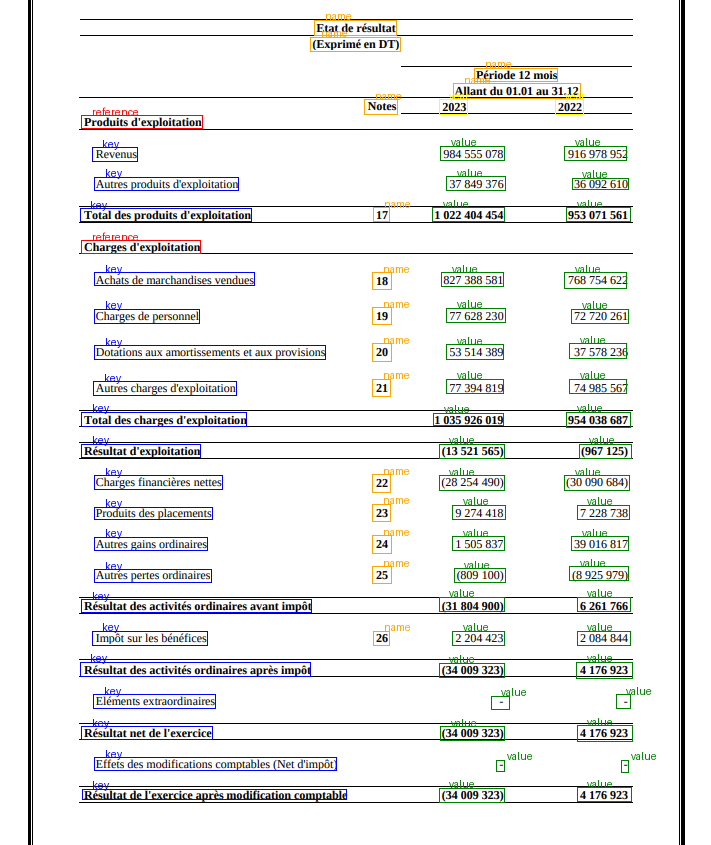

In [ ]:
from PIL import ImageDraw, ImageFont

draw = ImageDraw.Draw(image)

font = ImageFont.load_default()

def iob_to_label(label):
    label = label
    if not label:
      return 'other'
    return label

label2color = {'key':'blue', 'value':'green', 'name':'orange', 'reference': 'red', 'year': 'yellow'}

for prediction, box in zip(true_predictions, true_boxes):
    predicted_label = iob_to_label(prediction).lower()
    draw.rectangle(box, outline=label2color[predicted_label])
    draw.text((box[0] + 10, box[1] - 10), text=predicted_label, fill=label2color[predicted_label], font=font)

image